In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

## Startup Product analytics project

# Data loading

In [2]:
# our dataset is too big so we imported only 30k rows 
jan_df = pd.read_csv(r'E:\updateresumeprojects\python+pandas analysis\raw\2020-jan.csv',nrows=30000)


In [3]:
print(jan_df.shape)

(30000, 9)


In [4]:
jan_df.head(5)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-01-01 00:00:00 UTC,view,5809910,1602943681873052386,NaN,grattol,5.24,595414620,4adb70bb-edbd-4981-b60f-a05bfd32683a
1,2020-01-01 00:00:09 UTC,view,5812943,1487580012121948301,NaN,kinetics,3.97,595414640,c8c5205d-be43-4f1d-aa56-4828b8151c8a
2,2020-01-01 00:00:19 UTC,view,5798924,1783999068867920626,NaN,zinger,3.97,595412617,46a5010f-bd69-4fbe-a00d-bb17aa7b46f3
3,2020-01-01 00:00:24 UTC,view,5793052,1487580005754995573,NaN,NaN,4.92,420652863,546f6af3-a517-4752-a98b-80c4c5860711
4,2020-01-01 00:00:25 UTC,view,5899926,2115334439910245200,NaN,NaN,3.92,484071203,cff70ddf-529e-4b0c-a4fc-f43a749c0acb


In [5]:
jan_df.tail(5)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
29995,2020-01-01 13:36:32 UTC,view,5677366,1487580008246412266,NaN,estel,7.30,595583334,953af733-30bb-4fca-af2c-44bfa0984b04
29996,2020-01-01 13:36:33 UTC,view,5902336,1998040852064109417,NaN,freedecor,5.56,593892658,b929363d-69a1-4a34-a98b-5da61c1b7a41
29997,2020-01-01 13:36:34 UTC,view,5907840,1487580007675986893,NaN,NaN,1.43,531379381,c2227785-8697-44ec-8b4c-3c1b9c3097f3
29998,2020-01-01 13:36:35 UTC,view,5903766,1487580007675986893,NaN,NaN,1.59,486989548,85c5d7ec-9c1e-4f8e-8555-153bbbd2c335
29999,2020-01-01 13:36:35 UTC,view,5889094,1487580005092295511,NaN,NaN,4.44,462644899,e94e8a02-fae7-425c-9b34-6f98da4b4b0a


In [6]:
jan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   event_time     30000 non-null  object 
 1   event_type     30000 non-null  object 
 2   product_id     30000 non-null  int64  
 3   category_id    30000 non-null  int64  
 4   category_code  468 non-null    object 
 5   brand          16029 non-null  object 
 6   price          30000 non-null  float64
 7   user_id        30000 non-null  int64  
 8   user_session   29998 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 2.1+ MB


In [7]:
jan_df.isnull().sum()

event_time           0
event_type           0
product_id           0
category_id          0
category_code    29532
brand            13971
price                0
user_id              0
user_session         2
dtype: int64

In [8]:
jan_df['event_type'].nunique()

4

In [9]:
jan_df['product_id'].value_counts()#to get unique values and how many times they appear for a column

product_id
5809910    258
5700037    100
5809912     97
5877454     96
5802432     90
          ... 
18083        1
5903761      1
5760530      1
5840217      1
5903749      1
Name: count, Length: 9328, dtype: int64

In [10]:
jan_df['user_session'].nunique() # to get number of unique value in that column

7059

In [11]:
jan_df['price'].describe()

count    30000.000000
mean         9.312941
std         20.217713
min          0.000000
25%          2.380000
50%          4.130000
75%          7.460000
max        327.780000
Name: price, dtype: float64

## total rows 30000,total columns 9
### category_code  has 29532 null values
### brand column has 13971 null values 
### event_time has data type object

In [12]:
jan_df['event_type'].value_counts()

event_type
view                14406
cart                 8095
remove_from_cart     6126
purchase             1373
Name: count, dtype: int64

In [13]:
jan_df['event_time'] = pd.to_datetime(jan_df['event_time'])

In [14]:
jan_df['event_time'].dtype

datetime64[ns, UTC]

In [15]:
jan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   event_time     30000 non-null  datetime64[ns, UTC]
 1   event_type     30000 non-null  object             
 2   product_id     30000 non-null  int64              
 3   category_id    30000 non-null  int64              
 4   category_code  468 non-null    object             
 5   brand          16029 non-null  object             
 6   price          30000 non-null  float64            
 7   user_id        30000 non-null  int64              
 8   user_session   29998 non-null  object             
dtypes: datetime64[ns, UTC](1), float64(1), int64(3), object(4)
memory usage: 2.1+ MB


In [16]:
jan_df['user_id'].nunique()

5030

In [17]:
jan_df['product_id'].nunique()

9328

In [18]:
jan_df['user_session'].nunique()

7059

In [19]:
jan_df['category_code'].value_counts()

category_code
appliances.environment.vacuum      173
apparel.glove                       79
stationery.cartrige                 66
furniture.bathroom.bath             54
accessories.bag                     50
furniture.living_room.cabinet       31
appliances.personal.hair_cutter     10
accessories.cosmetic_bag             5
Name: count, dtype: int64

In [20]:
jan_df['brand'].value_counts()

brand
runail     1900
irisk      1206
grattol    1201
masura      830
bluesky     638
           ... 
riche         1
cruset        1
bergamo       1
inm           1
plazan        1
Name: count, Length: 198, dtype: int64

In [21]:
jan_df['hour'] = jan_df['event_time'].dt.hour

# Extract the day of the week (0=Monday, 6=Sunday)
jan_df['day_of_week'] = jan_df['event_time'].dt.dayofweek

# Extract day name (e.g., 'Monday', 'Tuesday') if you prefer text
jan_df['day_name'] = jan_df['event_time'].dt.day_name()

In [22]:
jan_df[['hour','day_of_week','day_name']].head(5)

,hour,day_of_week,day_name
0,0,2,Wednesday
1,0,2,Wednesday
2,0,2,Wednesday
3,0,2,Wednesday
4,0,2,Wednesday


### event_type view dominates user interaction
### we have 5030 unique users
### some products do not have brand name
### timestamps support time-based analysis
### runail is most popular brand 

In [23]:
jan_df['month_name'] = jan_df['event_time'].dt.month_name()

## Multiple files loading 

In [24]:
oct_df = pd.read_csv(r'E:\updateresumeprojects\python+pandas analysis\raw\2019-oct.csv',nrows=30000)

In [25]:
nov_df = pd.read_csv(r'E:\updateresumeprojects\python+pandas analysis\raw\2019-nov.csv',nrows=30000)

In [26]:
dec_df = pd.read_csv(r'E:\updateresumeprojects\python+pandas analysis\raw\2019-dec.csv',nrows=30000)

In [27]:
feb_df = pd.read_csv(r'E:\updateresumeprojects\python+pandas analysis\raw\2020-feb.csv',nrows=30000)

In [28]:
oct_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   event_time     30000 non-null  object 
 1   event_type     30000 non-null  object 
 2   product_id     30000 non-null  int64  
 3   category_id    30000 non-null  int64  
 4   category_code  706 non-null    object 
 5   brand          18026 non-null  object 
 6   price          30000 non-null  float64
 7   user_id        30000 non-null  int64  
 8   user_session   29998 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 2.1+ MB


In [29]:
dec_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   event_time     30000 non-null  object 
 1   event_type     30000 non-null  object 
 2   product_id     30000 non-null  int64  
 3   category_id    30000 non-null  int64  
 4   category_code  519 non-null    object 
 5   brand          17297 non-null  object 
 6   price          30000 non-null  float64
 7   user_id        30000 non-null  int64  
 8   user_session   29985 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 2.1+ MB


In [30]:
nov_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   event_time     30000 non-null  object 
 1   event_type     30000 non-null  object 
 2   product_id     30000 non-null  int64  
 3   category_id    30000 non-null  int64  
 4   category_code  539 non-null    object 
 5   brand          18313 non-null  object 
 6   price          30000 non-null  float64
 7   user_id        30000 non-null  int64  
 8   user_session   29962 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 2.1+ MB


In [31]:
feb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   event_time     30000 non-null  object 
 1   event_type     30000 non-null  object 
 2   product_id     30000 non-null  int64  
 3   category_id    30000 non-null  int64  
 4   category_code  538 non-null    object 
 5   brand          16692 non-null  object 
 6   price          30000 non-null  float64
 7   user_id        30000 non-null  int64  
 8   user_session   29997 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 2.1+ MB


In [32]:
oct_df['event_time'] = pd.to_datetime(oct_df['event_time'])
nov_df['event_time'] = pd.to_datetime(nov_df['event_time'])
dec_df['event_time'] = pd.to_datetime(dec_df['event_time'])
feb_df['event_time'] = pd.to_datetime(feb_df['event_time'])

In [33]:
oct_df['hour'] = oct_df['event_time'].dt.hour

oct_df['day_of_week'] = oct_df['event_time'].dt.dayofweek

oct_df['day_name'] = oct_df['event_time'].dt.day_name()

oct_df['month_name'] = oct_df['event_time'].dt.month_name()

In [34]:
nov_df['hour'] = nov_df['event_time'].dt.hour

nov_df['day_of_week'] = nov_df['event_time'].dt.dayofweek

nov_df['day_name'] = nov_df['event_time'].dt.day_name()

nov_df['month_name'] = nov_df['event_time'].dt.month_name()

In [35]:
dec_df['hour'] = dec_df['event_time'].dt.hour

dec_df['day_of_week'] = dec_df['event_time'].dt.dayofweek

dec_df['day_name'] = dec_df['event_time'].dt.day_name()

dec_df['month_name'] = dec_df['event_time'].dt.month_name()

In [36]:
feb_df['hour'] = feb_df['event_time'].dt.hour

feb_df['day_of_week'] = feb_df['event_time'].dt.dayofweek

feb_df['day_name'] = feb_df['event_time'].dt.day_name()

feb_df['month_name'] = feb_df['event_time'].dt.month_name()

# Combining all dataframes in one master dataframe

In [37]:
backup_data = pd.concat([oct_df,nov_df,dec_df,jan_df,feb_df],ignore_index=True)

In [38]:
master_df = pd.concat([oct_df,nov_df,dec_df,jan_df,feb_df],ignore_index=True)

In [39]:
master_df.shape

(150000, 13)

In [40]:
master_df.head(5)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,hour,day_of_week,day_name,month_name
0,2019-10-01 00:00:00+00:00,cart,5773203,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885,0,1,Tuesday,October
1,2019-10-01 00:00:03+00:00,cart,5773353,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885,0,1,Tuesday,October
2,2019-10-01 00:00:07+00:00,cart,5881589,2151191071051219817,NaN,lovely,13.48,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9,0,1,Tuesday,October
3,2019-10-01 00:00:07+00:00,cart,5723490,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885,0,1,Tuesday,October
4,2019-10-01 00:00:15+00:00,cart,5881449,1487580013522845895,NaN,lovely,0.56,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9,0,1,Tuesday,October


In [41]:
master_df.tail(5)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,hour,day_of_week,day_name,month_name
149995,2020-02-01 09:12:22+00:00,cart,5694628,1487580007835370453,NaN,yoko,3.65,474294636,aac24b1a-dd18-4df6-a85f-c6826805a942,9,5,Saturday,February
149996,2020-02-01 09:12:22+00:00,view,5857895,1487580012373606546,NaN,NaN,2.78,427570560,1ed7283e-6af0-425c-b4ab-f1c2876f1120,9,5,Saturday,February
149997,2020-02-01 09:12:23+00:00,cart,5694628,1487580007835370453,NaN,yoko,3.65,474294636,aac24b1a-dd18-4df6-a85f-c6826805a942,9,5,Saturday,February
149998,2020-02-01 09:12:23+00:00,cart,5694628,1487580007835370453,NaN,yoko,3.65,474294636,aac24b1a-dd18-4df6-a85f-c6826805a942,9,5,Saturday,February
149999,2020-02-01 09:12:23+00:00,cart,5694628,1487580007835370453,NaN,yoko,3.65,474294636,aac24b1a-dd18-4df6-a85f-c6826805a942,9,5,Saturday,February


In [42]:
master_df['month_name'].unique()

array(['October', 'November', 'December', 'January', 'February'],
      dtype=object)

In [43]:
duplicate_count  =  master_df.duplicated().sum()

In [44]:
print(duplicate_count)

9419


In [45]:
master_df[master_df.duplicated()]

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,hour,day_of_week,day_name,month_name
13,2019-10-01 00:00:30+00:00,remove_from_cart,5809103,1487580013522845895,NaN,irisk,0.60,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9,0,1,Tuesday,October
30,2019-10-01 00:01:05+00:00,remove_from_cart,5858981,1487580007634043851,NaN,de.lux,0.79,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9,0,1,Tuesday,October
36,2019-10-01 00:01:07+00:00,remove_from_cart,5312,1487580009471148064,NaN,runail,1.27,467916806,2f5b5546-b8cb-9ee7-7ecd-84276f8ef486,0,1,Tuesday,October
38,2019-10-01 00:01:10+00:00,remove_from_cart,5823915,1487580007432717250,NaN,milv,1.59,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9,0,1,Tuesday,October
51,2019-10-01 00:01:24+00:00,remove_from_cart,5664641,1487580011425693811,NaN,NaN,0.70,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9,0,1,Tuesday,October
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149937,2020-02-01 09:11:49+00:00,cart,5694628,1487580007835370453,NaN,yoko,3.65,474294636,aac24b1a-dd18-4df6-a85f-c6826805a942,9,5,Saturday,February
149938,2020-02-01 09:11:49+00:00,cart,5694628,1487580007835370453,NaN,yoko,3.65,474294636,aac24b1a-dd18-4df6-a85f-c6826805a942,9,5,Saturday,February
149939,2020-02-01 09:11:49+00:00,cart,5694628,1487580007835370453,NaN,yoko,3.65,474294636,aac24b1a-dd18-4df6-a85f-c6826805a942,9,5,Saturday,February
149998,2020-02-01 09:12:23+00:00,cart,5694628,1487580007835370453,NaN,yoko,3.65,474294636,aac24b1a-dd18-4df6-a85f-c6826805a942,9,5,Saturday,February


In [46]:
# there are duplicates but they are not exact duplicates like a complete row is not exactly same as duplicated one only column values are duplicated

In [47]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype              
---  ------         --------------   -----              
 0   event_time     150000 non-null  datetime64[ns, UTC]
 1   event_type     150000 non-null  object             
 2   product_id     150000 non-null  int64              
 3   category_id    150000 non-null  int64              
 4   category_code  2770 non-null    object             
 5   brand          86357 non-null   object             
 6   price          150000 non-null  float64            
 7   user_id        150000 non-null  int64              
 8   user_session   149940 non-null  object             
 9   hour           150000 non-null  int32              
 10  day_of_week    150000 non-null  int32              
 11  day_name       150000 non-null  object             
 12  month_name     150000 non-null  object             
dtypes: datetime64[ns, UTC](1), fl

In [48]:
master_df.isnull().sum()

event_time            0
event_type            0
product_id            0
category_id           0
category_code    147230
brand             63643
price                 0
user_id               0
user_session         60
hour                  0
day_of_week           0
day_name              0
month_name            0
dtype: int64

In [49]:
master_df['brand'] = master_df['brand'].fillna('Unknown')

In [50]:
master_df['price'].describe()

count    150000.000000
mean          8.876569
std          20.467360
min           0.000000
25%           2.050000
50%           3.970000
75%           7.140000
max         327.780000
Name: price, dtype: float64

In [51]:
master_df = master_df[master_df['price'] > 0]

In [52]:
master_df['event_type'].value_counts()

event_type
view                68329
cart                40529
remove_from_cart    29860
purchase             8752
Name: count, dtype: int64

In [53]:
master_df['month_name_2'] = master_df['event_time'].dt.month_name()

In [54]:

master_df['is_view'] = (master_df['event_type'] == 'view').astype(int)
master_df['is_cart'] = (master_df['event_type'] == 'cart').astype(int)
master_df['is_removed'] = (master_df['event_type'] == 'remove_from_cart').astype(int)
master_df['is_purchase'] = (master_df['event_type']== 'purchase').astype(int)
# Check the result
master_df[['event_type', 'is_view', 'is_cart', 'is_removed','is_purchase']].head(20)


,event_type,is_view,is_cart,is_removed,is_purchase
0,cart,0,1,0,0
1,cart,0,1,0,0
2,cart,0,1,0,0
3,cart,0,1,0,0
4,cart,0,1,0,0
5,cart,0,1,0,0
6,cart,0,1,0,0
7,cart,0,1,0,0
8,cart,0,1,0,0
9,view,1,0,0,0


## category code and brand has large amount of null values
## No datatype inconsistencies found
## there are duplicate values but whole rows are not duplicate column values are duplicate
## event type validate successfully and still view dominates user interaction
## purchases are low

In [55]:
week_days  = ['Saturday','Sunday']
master_df['is_weekend'] = (master_df['day_name'].isin(week_days)).astype(int)

In [56]:
def price_categorize(price):
    if price <50 :
        return 'Low'
    elif 50<=price<150:
        return 'Medium'
    elif 150<=price<250:
        return 'High'
    else:
        return 'Premium'
master_df['price_category'] = master_df['price'].apply(price_categorize)        

In [57]:
master_df['price_category'].value_counts()

price_category
Low        142882
Medium       3868
High          557
Premium       163
Name: count, dtype: int64

In [58]:
total_views = (master_df['event_type'] == 'view').sum()

In [59]:
total_carts = (master_df['event_type'] == 'cart').sum()
total_purchase = (master_df['event_type'] == 'purchase').sum()
total_removals = (master_df['event_type'] == 'remove_from_cart').sum()

In [60]:
view_to_cart_rate  = (master_df['is_cart'].sum()/master_df['is_view'].sum())*100
print(view_to_cart_rate) #drop off 39%

59.31449311419749


In [61]:
cart_to_purchase_rate = (master_df['is_purchase'].sum()/master_df['is_cart'].sum())*100
print(cart_to_purchase_rate) # drop off 80%

21.594413876483507


### Big drop off at cart_to_purchase_rate means people are liking but something is stopping them from buying

In [62]:
most_active_users = master_df['user_id'].value_counts().head(10)
print("Top 10 most active users :\n",most_active_users)

Top 10 most active users :
 user_id
494277072    832
576802932    699
557908761    381
599729176    309
608317073    287
595424692    265
505419579    255
579751441    255
580053614    253
595458066    246
Name: count, dtype: int64


In [63]:
session_per_user = master_df.groupby('user_id')['user_session'].nunique().reset_index()
session_per_user = session_per_user.sort_values(by='user_session',ascending=False)
session_per_user.head(10)

,user_id,user_session
15689,576802932,289
4061,476577170,186
12777,566083903,97
8774,549182787,94
15968,579179073,74
11574,557956487,73
8484,546603165,72
15804,577896990,71
21364,605044798,68
11765,559643851,63


In [64]:
hourly_activity = master_df.groupby('hour')['event_type'].count().reset_index()
hourly_activity.columns = ['Hour','activity']
hourly_activity

,Hour,activity
0,0,5867
1,1,4414
2,2,4300
3,3,6915
4,4,9271
5,5,15344
6,6,21514
7,7,25164
8,8,27519
9,9,10809


In [65]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_activity = master_df.groupby('day_name')['event_type'].count().reindex(day_order)
print(weekday_activity)

day_name
Monday           NaN
Tuesday      29958.0
Wednesday    29952.0
Thursday         NaN
Friday       29821.0
Saturday     27764.0
Sunday       29975.0
Name: event_type, dtype: float64


In [66]:
cart_abandonment_rate = 100-cart_to_purchase_rate
print(cart_abandonment_rate)

78.40558612351649


In [67]:
# products added to cart but not purchased
prod_stats = master_df.groupby('product_id').agg({'is_cart':'sum','is_purchase':'sum'})
abandoned_products =  prod_stats[(prod_stats['is_cart']>0) & (prod_stats['is_purchase']==0)]
# top 10 abandoned products
abandoned_products.sort_values(by='is_cart',ascending=False).head(10)

,is_cart,is_purchase
product_id,,
5742414,47,0
5783783,18,0
5806922,16,0
5843815,15,0
5899851,15,0
5838932,14,0
5842150,14,0
5665856,14,0
5752164,13,0


In [68]:
#category with higesh abandonment
cat_stats =  master_df.groupby('category_id').agg({'is_cart':'sum','is_purchase':'sum'})
cat_stats = cat_stats[cat_stats['is_cart'] > 10]
#calculate the rate
cat_stats['abandon_rate'] = (1 - (cat_stats['is_purchase'] / cat_stats['is_cart'])) * 100

# highest abandoned category
highest_abandoned_category = cat_stats.sort_values(by=['abandon_rate','is_cart'], ascending=False).head(1)
print(highest_abandoned_category)

                     is_cart  is_purchase  abandon_rate
category_id                                            
1526733091857498510       56            0         100.0


In [69]:
brand_performance =  master_df.groupby('brand').agg({'is_cart':'sum','is_purchase':'sum','is_view':'sum'}).reset_index()
brand_performance = brand_performance[brand_performance['is_cart'] > 5] # to ignore small values that does not matter 
#calculate the rate
brand_performance['abandon_rate'] = (1 - (brand_performance['is_purchase'] / brand_performance['is_cart'])) * 100
# 3. Filter for significance (brands with more than 5 carts) and sort
brand_performance = brand_performance.sort_values(by='is_purchase', ascending=False)
# highest abandoned brand
highest_abandoned_brand = brand_performance.sort_values(by=['abandon_rate','is_cart'], ascending=False).head(1)
print(highest_abandoned_brand)

        brand  is_cart  is_purchase  is_view  abandon_rate
83  farmavita       26            0      115         100.0


In [70]:
most_viewed_products = master_df.groupby('product_id')['is_view'].sum()
#top 5 most viewed products
most_viewed_products.sort_values(ascending=False).head(5)

product_id
5809910    646
5877454    258
5886282    244
5809912    235
5892179    215
Name: is_view, dtype: int64

In [71]:
most_purchased_products = master_df.groupby('product_id')['is_purchase'].sum()
#top 5 most purchased products
most_purchased_products.sort_values(ascending=False).head(5)

product_id
5809910    40
5854897    28
5849033    25
5751422    24
5700037    23
Name: is_purchase, dtype: int64

In [72]:
products_views_purchases = master_df.groupby('product_id').agg({'is_view':'sum','is_purchase':'sum'})
#top 10 products most viewd but not purchased
products_views_purchases.sort_values(by=['is_view','is_purchase'],ascending=[False,True]).head(10)

,is_view,is_purchase
product_id,,
5809910,646,40
5877454,258,6
5886282,244,3
5809912,235,19
5892179,215,12
5900651,192,15
5856186,182,1
5886064,169,3
5751383,166,17


In [73]:
purchases_by_hour = master_df.groupby('hour')['is_purchase'].sum().reset_index()
purchases_by_hour.columns = ['Hour','Total_purchases']
print(purchases_by_hour)

    Hour  Total_purchases
0      0              344
1      1              365
2      2              485
3      3              466
4      4              437
5      5              931
6      6             1438
7      7             1570
8      8             1502
9      9              525
10    10              140
11    11              244
12    12              177
13    13              128


In [74]:
weekday_purchases = master_df.groupby('day_name')['is_purchase'].sum().reindex(day_order)
weekday_purchases=weekday_purchases.reset_index().fillna(0)
weekday_purchases.columns = ['Day','Total_Purchases']
print(weekday_purchases)

         Day  Total_Purchases
0     Monday              0.0
1    Tuesday           2159.0
2  Wednesday           1373.0
3   Thursday              0.0
4     Friday           1985.0
5   Saturday           1414.0
6     Sunday           1821.0


In [75]:
weekday_engagement = master_df.groupby('day_name')['is_view'].sum().reindex(day_order)
weekday_engagement = weekday_engagement.reset_index().fillna(0)
weekday_engagement.columns = ['Day','Total_views']
print(weekday_engagement)

         Day  Total_views
0     Monday          0.0
1    Tuesday      13193.0
2  Wednesday      14359.0
3   Thursday          0.0
4     Friday      14082.0
5   Saturday      13140.0
6     Sunday      13555.0


In [76]:
# Group by month name to see total activity
monthly_engagement = master_df.groupby('month_name').agg({
    'is_view': 'sum',
    'is_cart': 'sum',
    'is_purchase': 'sum'
})

# Define the correct chronological order for months
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# Reindex to ensure months appear in order, not alphabetically
monthly_engagement = monthly_engagement.reindex(month_order).dropna()

print(monthly_engagement)

            is_view  is_cart  is_purchase
month_name                               
January     14359.0   8094.0       1373.0
February    13140.0   7532.0       1414.0
October     13193.0   8450.0       2159.0
November    14082.0   8033.0       1985.0
December    13555.0   8420.0       1821.0


In [77]:
monthly_engagement['purchase_growth_pct'] = monthly_engagement['is_purchase'].pct_change()*100
monthly_engagement['purchase_growth_pct'] = monthly_engagement['purchase_growth_pct'].fillna(0)

In [78]:
monthly_engagement['cart_growth_pct'] = monthly_engagement['is_cart'].pct_change()*100
monthly_engagement['cart_growth_pct'] = monthly_engagement['cart_growth_pct'].fillna(0)

In [79]:
monthly_engagement['engagement_growth_pct'] = monthly_engagement['is_view'].pct_change()*100
monthly_engagement['engagement_growth_pct'] = monthly_engagement['engagement_growth_pct'].fillna(0)

In [80]:
monthly_engagement = monthly_engagement.reset_index()

In [81]:
monthly_engagement.head(5)

,month_name,is_view,is_cart,is_purchase,purchase_growth_pct,cart_growth_pct,engagement_growth_pct
0,January,14359.0,8094.0,1373.0,0.000000,0.000000,0.000000
1,February,13140.0,7532.0,1414.0,2.986162,-6.943415,-8.489449
2,October,13193.0,8450.0,2159.0,52.687412,12.187998,0.403349
3,November,14082.0,8033.0,1985.0,-8.059287,-4.934911,6.738422
4,December,13555.0,8420.0,1821.0,-8.261965,4.817627,-3.742366


In [82]:
# 1. Group by hour and aggregate views and purchases
hourly_stats = master_df.groupby('hour').agg({
    'is_view': 'sum',      # Activity (Traffic)
    'is_purchase': 'sum'   # Results (Sales)
})

# 2. Calculate the Conversion Rate (%) per hour
hourly_stats['conversion_rate'] = (hourly_stats['is_purchase'] / hourly_stats['is_view']) * 100

# 3. Sort by Conversion Rate to find the most efficient hour
best_conv_hours = hourly_stats.sort_values(by='conversion_rate', ascending=False)

# 4. Display results
print(best_conv_hours.head(5))


      is_view  is_purchase  conversion_rate
hour                                       
2        1988          485        24.396378
1        1900          365        19.210526
3        3126          466        14.907230
6        9894         1438        14.534061
5        6943          931        13.409189


In [83]:
# Group by  is_weekend column (0 = Weekday, 1 = Weekend)
weekend_analysis = master_df.groupby('is_weekend').agg({
    'is_purchase': 'sum',      # Total Orders
    'price': 'mean',           # Average Order Value
    'is_view': 'sum'           # Traffic
}).reset_index()

# Calculate Conversion Rate
weekend_analysis['conversion_rate'] = (weekend_analysis['is_purchase'] / weekend_analysis['is_view']) * 100

# Rename the index for better readability in your project
weekend_analysis['day_type'] = weekend_analysis['is_weekend'].map({0: 'Weekday', 1: 'Weekend'})

print(weekend_analysis[['day_type', 'is_purchase', 'price', 'conversion_rate']])


  day_type  is_purchase     price  conversion_rate
0  Weekday         5517  9.157652        13.251189
1  Weekend         3235  8.828695        12.118374


# Business Insights & Analytical Findings
## Funnel & Conversion Analysis
### Product views dominated overall user interactions, indicating strong browsing activity across the platform.
### A major drop-off was observed between the cart and purchase stages, with nearly 80% cart abandonment rate.
### View-to-cart conversion remained significantly higher than cart-to-purchase conversion, highlighting friction in final purchase completion.
### Funnel analysis indicates that user intent is strong during product discovery but weak during checkout completion.

## User Engagement Insights
### User engagement was concentrated among a relatively small group of highly active users.
### Repeat sessions from active users contributed heavily to overall platform interactions.
### Certain hours of the day consistently generated higher purchase activity, indicating peak conversion windows.
### Weekend activity patterns differed from weekdays, suggesting user behavior changes based on time availability.

## Product & Category Intelligence
### Several products received very high view counts but low purchase conversions, indicating potential pricing, trust, or product relevance issues.
### Some categories experienced high cart activity but poor purchase completion, suggesting strong interest but weak conversion efficiency.
### Product segmentation analysis showed that customer interaction behavior varied across price categories.
### Premium-priced products showed lower conversion tendency compared to lower and medium-priced products.

## Time-Based Behavioral Insights
### Purchase activity varied significantly across different hours of the day.
### User engagement and conversion behavior showed noticeable weekday vs weekend differences.
### Monthly engagement trends revealed fluctuations in user interaction and purchasing behavior across different months.

## Analytical & Technical Contributions
### Built a multi-month master dataset by integrating transactional event data from multiple CSV files.
### Engineered behavioral indicator features such as purchase, cart, and engagement flags for simplified KPI analysis.
### Performed feature engineering using Python functions, conditional logic, and datetime transformations.
### Developed funnel analysis, engagement tracking, cart abandonment analysis, and product intelligence metrics using Python and Pandas.
### Applied analytical filtering techniques to avoid misleading insights from low-volume categories and brands.

# Export Analytical Tables For Power BI

#### First we make a funnel table containing KPIs

In [84]:
# 1. Calculate the Percentages
view_to_cart_pct = (total_carts / total_views) * 100
cart_to_purchase_pct = (total_purchase / total_carts) * 100
abandonment_pct = (1 - (total_purchase / total_carts)) * 100

# 2. Create the Table (DataFrame)
funnel_data = {
    'Metric': [
        'Total Views', 'Total Carts', 'Total Purchases', 'Total Removals', 
        'View-to-Cart Conversion %', 'Cart-to-Purchase Conversion %', 'Abandonment %'
    ],
    'Value': [
        total_views, total_carts, total_purchase, total_removals,
        f"{view_to_cart_pct:.2f}%", f"{cart_to_purchase_pct:.2f}%", f"{abandonment_pct:.2f}%"
    ]
}

funnel_table = pd.DataFrame(funnel_data)
funnel_table


,Metric,Value
0,Total Views,68329
1,Total Carts,40529
2,Total Purchases,8752
3,Total Removals,29860
4,View-to-Cart Conversion %,59.31%
5,Cart-to-Purchase Conversion %,21.59%
6,Abandonment %,78.41%


In [85]:
# we already created monthly engagement table 
monthly_engagement.head(5)

,month_name,is_view,is_cart,is_purchase,purchase_growth_pct,cart_growth_pct,engagement_growth_pct
0,January,14359.0,8094.0,1373.0,0.000000,0.000000,0.000000
1,February,13140.0,7532.0,1414.0,2.986162,-6.943415,-8.489449
2,October,13193.0,8450.0,2159.0,52.687412,12.187998,0.403349
3,November,14082.0,8033.0,1985.0,-8.059287,-4.934911,6.738422
4,December,13555.0,8420.0,1821.0,-8.261965,4.817627,-3.742366


In [86]:
# now for hour table we already have hourly activiy and hourly purchases we jsu need to calculate hourly engagement and then make it a table 
hourly_engagement = master_df.groupby('hour')['is_view'].sum().reset_index()
hourly_engagement.columns= ['Hour','Engagement']

In [87]:
Hourly_Activity_Table = pd.merge(hourly_activity, hourly_engagement, on='Hour')
Hourly_Activity_Table = pd.merge(Hourly_Activity_Table, purchases_by_hour, on='Hour')
Hourly_Activity_Table.columns = ['hour', 'total_activity', 'total_views', 'total_purchases']

In [88]:
Hourly_Activity_Table.head(5)

,hour,total_activity,total_views,total_purchases
0,0,5867,2691,344
1,1,4414,1900,365
2,2,4300,1988,485
3,3,6915,3126,466
4,4,9271,4475,437


In [89]:
# weekly_activity_table
weekly_activity_table = pd.merge(weekday_engagement,weekday_purchases,on="Day")
weekly_activity_table['day_type'] = weekly_activity_table['Day'].apply(lambda x : 'weekend' if x in ['Saturday','Sunday'] else 'weekday')
weekly_activity_table['conversion_rate'] = (weekly_activity_table['Total_Purchases'] / weekly_activity_table['Total_views']) * 100

In [90]:
weekly_activity_table = weekly_activity_table.fillna(0)
weekly_activity_table.head(5)

,Day,Total_views,Total_Purchases,day_type,conversion_rate
0,Monday,0.0,0.0,weekday,0.000000
1,Tuesday,13193.0,2159.0,weekday,16.364739
2,Wednesday,14359.0,1373.0,weekday,9.561947
3,Thursday,0.0,0.0,weekday,0.000000
4,Friday,14082.0,1985.0,weekday,14.096009


In [91]:
# Category performance table
category_performance = master_df.groupby('category_id').agg({
    'is_view': 'sum',      # Engagement metric
    'is_cart': 'sum',      # Shopping intent
    'is_purchase': 'sum',  # Revenue metric
    'price': 'mean'        # Average price in category
}).reset_index()

# 2. Calculate the Abandonment Rate (%)
# (1 - (Purchases / Carts)) * 100
category_performance['abandonment_rate'] = (
    1 - (category_performance['is_purchase'] / category_performance['is_cart'])
) * 100

# 3. Calculate View-to-Purchase (Overall Conversion)
category_performance['conversion_rate'] = (
    category_performance['is_purchase'] / category_performance['is_view']
) * 100

# 4. Filter for categories with at least 5 carts to keep data "Strong"
category_performance = category_performance[category_performance['is_cart'] > 5]

# 5. Clean up the names and sort by highest abandonment
category_performance = category_performance.rename(columns={
    'is_view': 'total_views',
    'is_cart': 'total_carts',
    'is_purchase': 'total_purchases',
    'price': 'avg_price'
}).sort_values(by='abandonment_rate', ascending=False)

category_performance.head(10)


,category_id,total_views,total_carts,total_purchases,avg_price,abandonment_rate,conversion_rate
392,1962525126503170858,4,11,0,6.350000,100.0,0.0
377,1911999801642189621,13,6,0,4.526400,100.0,0.0
362,1819693959081886239,23,29,0,6.510000,100.0,0.0
372,1897124469017673788,18,9,0,6.267895,100.0,0.0
352,1783999076535108182,10,7,0,12.188000,100.0,0.0
351,1783999073792033086,27,12,0,9.638372,100.0,0.0
348,1783999072365969578,15,6,0,13.681111,100.0,0.0
92,1487580007701152718,3,6,0,1.476000,100.0,0.0
311,1588205336064425989,25,10,0,8.341053,100.0,0.0
302,1526733091857498510,57,56,0,5.977862,100.0,0.0


In [92]:
#brand performance table we have already created earlier
brand_performance.head(5)

,brand,is_cart,is_purchase,is_view,abandon_rate
0,Unknown,16933,3612,27924,78.668871
201,runail,3729,961,4632,74.229016
112,irisk,3273,726,3036,77.818515
158,masura,1810,320,2247,82.320442
98,grattol,1250,279,2627,77.680000


In [93]:
# product intelligence table
product_intelligence = master_df.groupby('product_id').agg({
    'is_view': 'sum',
    'is_purchase': 'sum',
    'price': 'mean'
}).reset_index()

# 2. Calculate Conversion Rate
product_intelligence['conversion_rate'] = (product_intelligence['is_purchase'] / product_intelligence['is_view']) * 100

# 3. Flag "Low Conversion" products (High views but conversion < 1%)
product_intelligence['status'] = product_intelligence.apply(
    lambda x: 'Low Conversion' if x['is_view'] > 50 and x['conversion_rate'] < 1 else 'Normal', axis=1
)

product_intelligence.sort_values(by='is_view', ascending=False).head(10)


,product_id,is_view,is_purchase,price,conversion_rate,status
10161,5809910,646,40,5.24,6.191950,Normal
19450,5877454,258,6,44.29,2.325581,Normal
20508,5886282,244,3,21.59,1.229508,Normal
10163,5809912,235,19,5.24,8.085106,Normal
21299,5892179,215,12,18.89,5.581395,Normal
22183,5900651,192,15,19.52,7.812500,Normal
16372,5856186,182,1,75.40,0.549451,Low Conversion
20495,5886064,169,3,15.71,1.775148,Normal
6141,5751383,166,17,10.32,10.240964,Normal
15275,5849033,165,25,10.32,15.151515,Normal


In [94]:
# 1. User engagement table
user_engagement = master_df.groupby('user_id').agg({
    'user_session': 'nunique',
    'is_view': 'sum',
    'is_cart': 'sum',
    'is_purchase': 'sum'
}).reset_index()

# 2. Rename for clarity
user_engagement.columns = ['user_id', 'total_sessions', 'total_views', 'total_carts', 'total_purchases']

# 3. Sort by top active users (most sessions)
user_engagement = user_engagement.sort_values(by='total_sessions', ascending=False)

user_engagement.head(10)


,user_id,total_sessions,total_views,total_carts,total_purchases
15689,576802932,289,287,5,64
4061,476577170,186,186,0,0
12777,566083903,97,96,15,0
8774,549182787,94,98,5,0
15968,579179073,74,76,13,0
11574,557956487,73,89,12,0
8484,546603165,72,111,21,0
15804,577896990,71,71,0,0
21364,605044798,68,77,5,0
11765,559643851,63,63,9,0


# Tables To Export
## Master_df (fact_table)
## Monthly engagement
## Category performance
## Product intelligence 

### these 4 are enough for our dashboard for trend analysis,detailed analysis,category intelligence,product intelligence

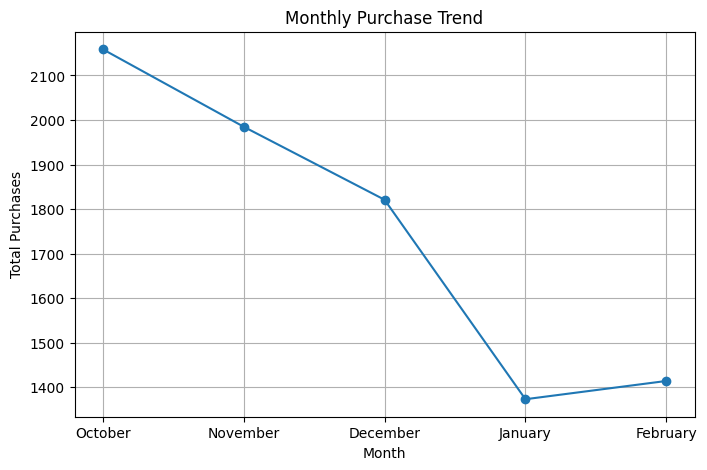

In [99]:
monthly_purchases = master_df.groupby('month_name')['is_purchase'].sum().reindex(
    ['October', 'November', 'December', 'January', 'February']
)

plt.figure(figsize=(8,5))

plt.plot(
    monthly_purchases.index,
    monthly_purchases.values,
    marker='o'
)

plt.title('Monthly Purchase Trend')
plt.xlabel('Month')
plt.ylabel('Total Purchases')

plt.grid(True)

plt.show()

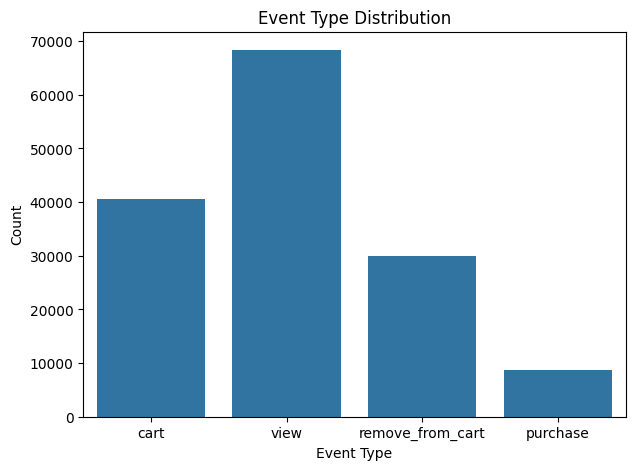

In [100]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=master_df,
    x='event_type'
)

plt.title('Event Type Distribution')
plt.xlabel('Event Type')
plt.ylabel('Count')

plt.show()

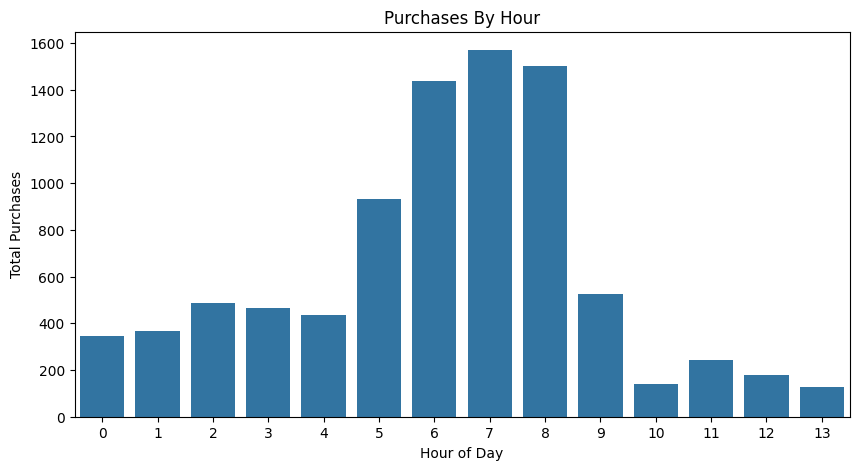

In [103]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=purchases_by_hour,
    x='Hour',
    y='Total_purchases'
)

plt.title('Purchases By Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Total Purchases')

plt.show()

In [104]:
master_df.to_csv(r'E:\updateresumeprojects\python+pandas analysis\Power bi files\fact_user_events.csv',index=False)
monthly_engagement.to_csv(r'E:\updateresumeprojects\python+pandas analysis\Power bi files\monthly_kpi_summary.csv',index=False)
category_performance.to_csv(r'E:\updateresumeprojects\python+pandas analysis\Power bi files\category_performance_summary.csv',index=False)
product_intelligence.to_csv(r'E:\updateresumeprojects\python+pandas analysis\Power bi files\product_conversion_analysis.csv',index=False)